# 📊 Análisis Cuantitativo de SBOMs y Vulnerabilidades

## EbookFoundation - Organismo de Análisis

Este notebook analiza los resultados del pipeline DevSecOps:

## 1. Cargar Datos

In [1]:
import json
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

# Ruta para datos - funciona en local y Docker
if Path('/app/data/raw').exists():
    DATA_DIR = Path('/app/data/raw')
else:
    DATA_DIR = Path(__file__).parent / '..' / 'pipeline' / 'data' / 'raw'

print(f"DATA_DIR: {DATA_DIR}")

sbom_files = sorted(DATA_DIR.glob("sbom_*.json"))
sca_files = sorted(DATA_DIR.glob("sca_*.json"))
sast_files = sorted(DATA_DIR.glob("sast_*.json"))

print(f"SBOMs: {len(sbom_files)}")
print(f"SCA: {len(sca_files)}")
print(f"SAST: {len(sast_files)}")

DATA_DIR: /app/data/raw
SBOMs: 35
SCA: 35
SAST: 35


## 2. Cargar SBOMs

In [3]:
def load_sboms(data_dir):
    """Carga todos los archivos SBOM y los estructura en DataFrame."""
    sbom_data = []
    for f in data_dir.glob("sbom_*.json"):
        repo_name = f.stem.replace("sbom_", "")
        with open(f, 'r') as fp:
            data = json.load(fp)
        artifacts = data.get("artifacts", [])
        for art in artifacts:
            sbom_data.append({
                "repo": repo_name,
                "name": art.get("name"),
                "version": art.get("version"),
                "type": art.get("type"),
                "language": art.get("language"),
                "license": art.get("metadata", {}).get("licenses")
            })
    return pd.DataFrame(sbom_data)

df_sbom = load_sboms(DATA_DIR)
df_sbom.head()

,repo,name,version,type,language,license
0,regluit-provisioning,ansible,2.10.7,python,python,None
1,regluit-provisioning,ansible-base,2.10.17,python,python,None
2,regluit-provisioning,cffi,1.15.0,python,python,None
3,regluit-provisioning,cryptography,37.0.1,python,python,None
4,regluit-provisioning,jinja2,3.1.2,python,python,None


In [4]:
print(f"Total de paquetes: {len(df_sbom)}")
print(f"Repositorios únicos: {df_sbom['repo'].nunique()}")

Total de paquetes: 3971
Repositorios únicos: 17


## 3. Análisis de SBOMs

In [5]:
# Paquetes por repositorio
packages_per_repo = df_sbom.groupby("repo").size().sort_values(ascending=False)
print("Top 10 repositorios con más paquetes:")
print(packages_per_repo.head(10))

Top 10 repositorios con más paquetes:
repo
free-programming-books-search    1581
regluit                          1322
thoth                             466
oapen-suggestion-service          242
roe-pressbooks                    129
alt-text-frontend                  74
autocat3                           44
cce-search-prototype               22
free-programming-books             18
doab-check                         16
dtype: int64


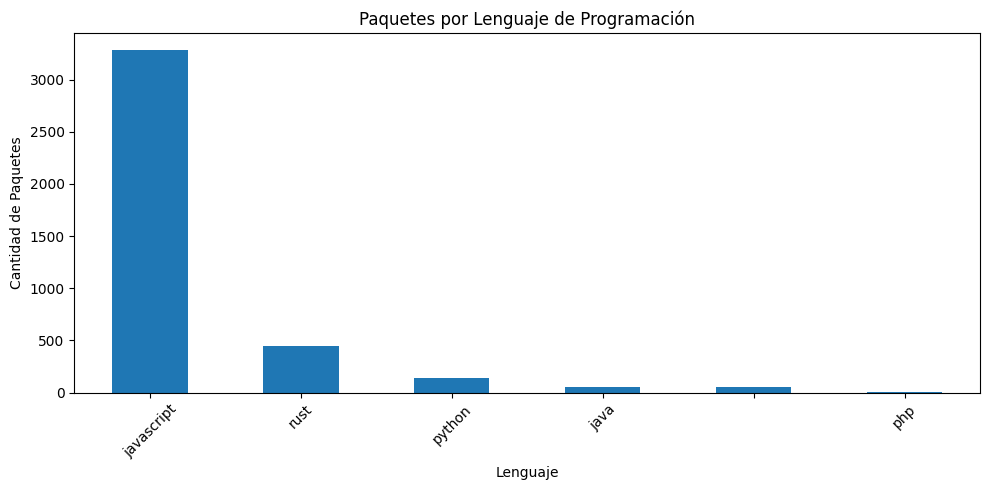

In [6]:
# Distribución por lenguaje
plt.figure(figsize=(10, 5))
language_counts = df_sbom["language"].value_counts().head(10)
language_counts.plot(kind="bar")
plt.title("Paquetes por Lenguaje de Programación")
plt.xlabel("Lenguaje")
plt.ylabel("Cantidad de Paquetes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Cargar Análisis de Dependencias (SCA)

In [7]:
def load_sca(data_dir):
    """Carga archivos de vulnerabilidades SCA."""
    vuln_data = []
    for f in data_dir.glob("sca_*.json"):
        repo_name = f.stem.replace("sca_", "")
        try:
            with open(f, 'r') as fp:
                data = json.load(fp)
            matches = data.get("matches", [])
            for m in matches:
                vuln_data.append({
                    "repo": repo_name,
                    "vulnerability": m.get("vulnerability", {}).get("id"),
                    "severity": m.get("vulnerability", {}).get("severity"),
                    "pkg_name": m.get("artifact", {}).get("name"),
                    "pkg_version": m.get("artifact", {}).get("version"),
                    "fix": m.get("vulnerability", {}).get("fixedInVersion")
                })
        except Exception as e:
            print(f"Error {f.name}: {e}")
    return pd.DataFrame(vuln_data)

df_sca = load_sca(DATA_DIR)
df_sca.head()

,repo,vulnerability,severity,pkg_name,pkg_version,fix
0,regluit-provisioning,GHSA-x4qr-2fvf-3mr5,High,cryptography,37.0.1,None
1,regluit-provisioning,GHSA-3ww4-gg4f-jr7f,High,cryptography,37.0.1,None
2,regluit-provisioning,GHSA-jfhm-5ghh-2f97,Medium,cryptography,37.0.1,None
3,regluit-provisioning,GHSA-h75v-3vvj-5mfj,Medium,jinja2,3.1.2,None
4,regluit-provisioning,GHSA-w7pp-m8wf-vj6r,Medium,cryptography,37.0.1,None


In [8]:
print(f"Total de vulnerabilidades: {len(df_sca)}")
print(f"Repositorios afectados: {df_sca['repo'].nunique()}")

Total de vulnerabilidades: 898
Repositorios afectados: 16


## 5. Análisis de Vulnerabilidades

In [ ]:
# Vulnerabilidades por severidad
severity_counts = df_sca["severity"].value_counts()
print("Vulnerabilidades por severidad:")
print(severity_counts)

In [ ]:
# Plot de severidad
plt.figure(figsize=(8, 5))
severity_counts.plot(kind="bar", color=["red", "orange", "yellow"])
plt.title("Vulnerabilidades por Severidad")
plt.xlabel("Severidad")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 paquetes con más vulnerabilidades
top_vuln_pkgs = df_sca.groupby("pkg_name").size().sort_values(ascending=False).head(10)
print("Top 10 paquetes más vulnerables:")
print(top_vuln_pkgs)

## 6. Cargar Análisis SAST

In [ ]:
def load_sast(data_dir):
    """Carga hallazgos SAST de Semgrep."""
    sast_data = []
    for f in data_dir.glob("sast_*.json"):
        repo_name = f.stem.replace("sast_", "")
        try:
            with open(f, 'r') as fp:
                data = json.load(fp)
            results = data.get("results", [])
            for r in results:
                sast_data.append({
                    "repo": repo_name,
                    "check_id": r.get("check_id"),
                    "file": r.get("path"),
                    "line": r.get("start", {}).get("line"),
                    "severity": r.get("extra", {}).get("severity", "INFO")
                })
        except Exception as e:
            print(f"Error {f.name}: {e}")
    return pd.DataFrame(sast_data)

df_sast = load_sast(DATA_DIR)
print(f"Total hallazgos SAST: {len(df_sast)}")

## 7. Resumen Ejecutivo

In [ ]:
print("=" * 50)
print("RESUMEN EJECUTIVO - EbookFoundation")
print("=" * 50)
print(f"Repositorios analizados: {len(sbom_files)}")
print(f"Total de paquetes detectados: {len(df_sbom)}")
print(f"Lenguajes únicos: {df_sbom['language'].nunique()}")
print()
print(f"Vulnerabilidades (SCA): {len(df_sca)}")
print(f"Repositorios con vulnerabilidades: {df_sca['repo'].nunique()}")
print()
print(f"Hallazgos SAST: {len(df_sast)}")
print("=" * 50)